In [1]:
from langchain_core.messages import AIMessage
from langchain_core.tools import tool


from langgraph.prebuilt import ToolNode
import os
import getpass

In [2]:
def _set_if_undefined(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"Please provide your {var}")


_set_if_undefined("OPENAI_API_KEY")
_set_if_undefined("LANGCHAIN_API_KEY")
# _set_if_undefined("TAVILY_API_KEY")

# Optional, add tracing in LangSmith.
# This will help you visualize and debug the control flow
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "inbox-manager"

In [3]:
@tool
def get_weather(location: str):
    """Call to get the current weather."""
    if location.lower() in ["sf", "san francisco"]:
        return "It's 60 degrees and foggy."
    else:
        return "It's 90 degrees and sunny."


@tool
def get_coolest_cities():
    """Get a list of coolest cities"""
    return "nyc, sf"

# @tool 

# def get_calendar_availablilty(date: str):
#     """get available dates for calendaar"""
#     return {"messages": "i am available for {date}"}
    

In [4]:
import sys
import os

# Get the parent directory
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Add parent directory to sys.path
sys.path.append(parent_dir)


In [5]:
from tools.product_enquiry import get_product_enquiry_tool
# from tools.product_enquiry import get_integrations
from tools.calendar import calender_check
from tools.project_management import project_management


In [6]:
from typing import Annotated

from langchain_core.tools import tool
from langchain_core.tools.base import InjectedToolCallId
from langgraph.prebuilt import InjectedState
from langchain_openai import ChatOpenAI
from langgraph.types import Command
from utils import make_handoff_tool

In [7]:
drafter_tools = [get_product_enquiry_tool(),make_handoff_tool(agent_name="calendar_agent")]
calendar_tools = [calender_check, make_handoff_tool(agent_name="email_drafter")]

tool_node = ToolNode(drafter_tools)

called product enquiry tool


d:\innovizeai\code-sapien\inbox-manager\utils.py:22: LangChainDeprecationWarning: The class `Qdrant` was deprecated in LangChain 0.0.37 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-qdrant package and should be used instead. To use it run `pip install -U :class:`~langchain-qdrant` and import as `from :class:`~langchain_qdrant import Qdrant``.
  qd = Qdrant(client, collection_name, embeddings)
d:\innovizeai\code-sapien\inbox-manager\tools\product_enquiry.py:40: LangChainBetaWarning: This API is in beta and may change in the future.
  return product_enquiry_tool.as_tool()


In [8]:
def first_node():
    return "first node"

In [9]:
def second_node():
    return "second node"

In [10]:
from typing import Literal
from langchain_openai import ChatOpenAI
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_anthropic import ChatAnthropic
from langgraph.graph import StateGraph, MessagesState
from langgraph.prebuilt import ToolNode

query = "What is the capital of France?"

prompt= f"respond in italian {query}"

model_with_tools =  ChatOpenAI(
    model="gpt-4o-mini", temperature=0
).bind_tools(drafter_tools, tool_choice="auto")

print(prompt.format(query))
# response = model_with_tools.invoke(prompt.format(query))


respond in italian What is the capital of France?


In [11]:
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, AIMessage, ChatMessage

In [12]:
from prompts.prompts import EMAIL_DRAFTER_PROMPT

In [13]:
# response

In [14]:
from langgraph.graph import START, StateGraph
from state import AgentGraphState

In [15]:
import datetime

In [16]:
from langgraph.types import Command

In [17]:
# def subgraph_node_1(state: AgentGraphState):
#     return {"sender_email_id": "pavan@gmail.com"}


# def subgraph_node_2(state: AgentGraphState):
#     # note that this node is using a state key ('bar') that is only available in the subgraph
#     # and is sending update on the shared state key ('foo')
    
#     return Command(goto="calendar" )


# subgraph_builder = StateGraph(AgentGraphState)
# subgraph_builder.add_node(subgraph_node_1)
# subgraph_builder.add_node(subgraph_node_2)
# # subgraph_builder.add_node("calendar", calendar)
# subgraph_builder.add_edge(START, "subgraph_node_1")
# subgraph_builder.add_edge("subgraph_node_1", "subgraph_node_2")
# subgraph3 = subgraph_builder.compile()

In [18]:
# from IPython.display import Image, display

# # Setting xray to 1 will show the internal structure of the nested graph
# display(Image(subgraph3.get_graph(xray=1).draw_mermaid_png()))

In [19]:
# subgraph3.invoke({"raw_email_body": "this is test message and lets create a meet at 3PM next weeek tuesday"})

In [20]:
# model_with_tools.invoke("""I came across your post about AI automation and wanted to learn more about how it could improve my business processes. Can you share more details about what industries you specialize in?????""").tool_calls


In [21]:
# tool_node.invoke({"messages": [model_with_tools.invoke("I came across your post about AI automation and wanted to learn more about how it could improve my business processes. Can you share more details about what industries you specialize in??????")]})

In [22]:
# email_drafter_graph= create_email_drafter_graph(drafter_tools)

# calendar_graph= create_calendar_graph(calendar_tools)

In [23]:
# response= email_drafter_graph.invoke( {"messages": "Hi Pavan Kumar,\nHi Team,\nwhat is your pricing and lets setup a call?"})

In [24]:
# response

In [25]:
# example with a single tool call
# for chunk in email_drafter_graph.stream(
#     {"messages": [("human", "I came across your post about AI automation and wanted to learn more about how it could improve my business processes. Can you share more details about what industries you specialize in???")]}, stream_mode="values"
# ):
#     chunk["messages"][-1].pretty_print()

In [26]:
# def email_drafter(state:AgentGraphState):
#     response = email_drafter_graph.invoke({"messages": state["processed_email_body"]})
#     return {"messages": [response]}

In [27]:
from typing import Literal

from langgraph.graph import StateGraph, MessagesState, START, END
from drafter_graph import create_email_drafter_graph
from agents.categorizer import EmailCategorizer
from agents.email_generator import EmailGenerator
from agents.node import Node
from state import AgentGraphState
from agents.drafter import EmailDrafter
from agents.calendar import CalendarAgent
# def should_continue(state: MessagesState):
#     messages = state["messages"]
#     last_message = messages[-1]
#     if last_message.tool_calls:
#         return "tools"
#     return END


# def call_model(state: MessagesState):
#     messages = state["messages"]
#     response = model_with_tools.invoke(messages)
#     return {"messages": [response]}



from state import state
from agents.preprocessor import Preprocess
from agents.supervisor import Supervisor
workflow = StateGraph(AgentGraphState)

# def should_respond(state: AgentGraphState) -> Literal["email_drafter", "end"]:
#     """Complex routing logic"""
#     if state["needs_response"] == "Needs Response":
#         print("should start the email drafter model")
#         return "email_drafter"
#     return END

email_categorizer= EmailCategorizer(
    state= state,
    model="gpt-4o",
    server="openai"
)

preprocess_email= Preprocess(state= state)
email_generator= EmailGenerator(state, model= "gpt-4o-mini", server= "openai")

product_enquiry_agent= EmailDrafter(
        model= "gpt-4o-mini",
        server="openai"
    )
product_enquiry_agent.bind_tools([get_product_enquiry_tool()])
calendar_agent= CalendarAgent(
        model= "gpt-4o-mini",
        server="openai"
    )
calendar_agent.bind_tools( [calender_check])

email_supervisor= Supervisor(
    model="claude-3-5-sonnet-latest",
    server="claude",
    members=["product_enquiry_agent", "calendar_agent"]
)

from langgraph.prebuilt import create_react_agent

llm= ChatOpenAI(model= "gpt-4o")
# product_enquiry_agent= create_react_agent(llm,[get_product_enquiry_tool()] )
# calendar_agent=create_react_agent(llm, [calender_check])
def final_node(state: AgentGraphState):
    email_draft =state['email_output'].email_draft
    confidence= state['email_output'].confidence
    hand_off_human=state['email_output'].hand_off_to_human
    print("email draft final node" ,email_draft)

    return state
# email_preproccessor= preprocess_email()
# email_drafter_graph= create_email_drafter_graph(tools)
# subgraph2= create_email_drafter_graph(tools)
# graph = create_react_agent(model, tools=tools, state_modifier=prompt)

def product_enquiry_node(state: AgentGraphState) -> Command[Literal["supervisor"]]:
    result = product_enquiry_agent.invoke(state)
    return Command(
        update={
            "messages": [
                HumanMessage(content=result["messages"][-1].content, name="product_enquiry_agent")
            ]
        },
        # We want our workers to ALWAYS "report back" to the supervisor when done
        goto="supervisor",
    )
def calendar_enquiry_node(state: AgentGraphState) -> Command[Literal["supervisor"]]:
    result = calendar_agent.invoke(state)
    return Command(
        update={
            "messages": [
                HumanMessage(content=result["messages"][-1].content, name="calendar_agent")
            ]
        },
        # We want our workers to ALWAYS "report back" to the supervisor when done
        goto="supervisor",
    )

email_supervisor_node= email_supervisor.make_supervisor_node()

# workflow.add_node("email_preprocessor",preprocess_email.preprocess_email)
# workflow.add_node("email_categorizer", email_categorizer.invoke)
workflow.add_node("product_enquiry_agent",product_enquiry_agent.create_agent_graph)
workflow.add_node("calendar_agent",calendar_agent.create_agent_graph)
workflow.add_node("supervisor", email_supervisor_node)
workflow.add_node("final_response", final_node)
workflow.add_node("email_generator", email_generator.generate)
# workflow.add_node("subgraph2",subgraph3)

workflow.add_edge(START, "supervisor")
# workflow.add_edge("product_enquiry_agent","email_supervisor")
# workflow.add_edge("calendar_agent","email_supervisor")


# workflow.add_node("second_node",second_node)
# workflow.add_edge("first_node", "email_preprocessor")
# workflow.add_edge("email_preprocessor","email_categorizer")
# workflow.add_conditional_edges("email_categorizer", should_respond, ["email_drafter", END])
# workflow.add_edge("email_drafter", "email_generator")
# workflow.add_edge("calendar_agent","email_generator")
workflow.add_edge("email_generator","final_response")
workflow.add_edge("final_response",END)
# Define the two nodes we will cycle between
# workflow.add_node("drafter",  )
# workflow.add_node("tools", tool_node)
# workflow.add_edge("tools","second_node")
# workflow.add_conditional_edges("drafter", should_continue, ["tools", END])
# workflow.add_edge("tools", "drafter")

graph = workflow.compile()

called product enquiry tool


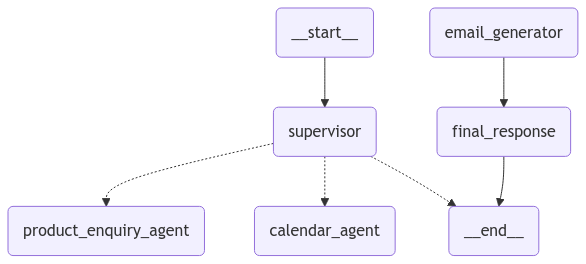

In [28]:
from IPython.display import Image, display

# Setting xray to 1 will show the internal structure of the nested graph
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [29]:
response= graph.invoke({
    
    "raw_email_body":"""<html><body> Hi Pavan Kumar,
 Can you share some casetudies in education.are you available next week tuesday for a quick call?????
</body></html>""",
    "company_domain_name": "innovizeai.com",
    "sender_email_id":"pavan.kumar@innovizeai.com",
    "messages": [HumanMessage(content="Can you share some casetudies in real estate.are you available next tuesday 3PM for a quick call???")]
})

messages from supervisor node [{'role': 'system', 'content': "You are a supervisor tasked with managing a conversation between the following workers: ['product_enquiry_agent', 'calendar_agent']. Given the following user request, respond with the worker to act next. Each worker will perform a task and respond with their results and status. When finished, respond with FINISH."}, HumanMessage(content='Can you share some casetudies in real estate.are you available next tuesday 3PM for a quick call???', additional_kwargs={}, response_metadata={}, id='f896cff8-400d-40f3-a57f-e4d96c4a7f0f')]
models llm model='claude-3-5-sonnet-latest' temperature=0.0 anthropic_api_url='https://api.anthropic.com' anthropic_api_key=SecretStr('**********') model_kwargs={}
go to from supervisor node calendar_agent
messages [HumanMessage(content='Can you share some casetudies in real estate.are you available next tuesday 3PM for a quick call???', additional_kwargs={}, response_metadata={}, id='f896cff8-400d-40f3-a

KeyboardInterrupt: 

: 

In [30]:
# for chunk in graph.stream({
    
#     "raw_email_body":"""<html><body> Hi Pavan Kumar,
# Hi Team,
# what is your pricing and lets setup a call?</body></html>""",
#     "company_domain_name": "innovizeai.com",
#     "sender_email_id":"pavan.kumar@innovizeai.com"
# }, subgraphs=True):
#     print(chunk)

In [ ]:
response